In [33]:
# pipenv install scikit-learn scipy pandas matplotblib seaborn ipykernel

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [34]:
# Carregar o arquivo
df_colesterol = pd.read_csv('dataset_colesterol.csv')

In [35]:
# Checar arquivo
df_colesterol.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Id                  1000 non-null   int64  
 1   Grupo Sanguíneo     996 non-null    str    
 2   Fumante             997 non-null    str    
 3   Nível de Atividade  996 non-null    str    
 4   Idade               997 non-null    float64
 5   Peso                997 non-null    float64
 6   Altura              997 non-null    float64
 7   Colesterol          1000 non-null   float64
dtypes: float64(4), int64(1), str(3)
memory usage: 62.6 KB


In [36]:
# Remover coluna ID
df_colesterol.drop(columns=['Id'], inplace=True)

In [37]:
df_colesterol.columns = [
  'grupo_sanguinio',
  'fumante',
  'nivel_atividade_fisica', 
  'idade',
  'peso',
  'altura',
  'nivel_colesterol'
]

In [38]:
# Copiar DF para DF EDA
df_colesterol_eda = df_colesterol.copy()

In [39]:
# Copiar DF para DF Bucketing
df_colesterol_bucketing = df_colesterol.copy()

In [40]:
# Visualizar os dados
df_colesterol_eda.head(10)

,grupo_sanguinio,fumante,nivel_atividade_fisica,idade,peso,altura,nivel_colesterol
0,B,Sim,Baixo,33.0,85.1,186.0,199.63
1,A,Não,Moderado,68.0,105.0,184.0,236.98
2,O,Não,Alto,25.0,64.8,180.0,161.79
3,A,Não,Alto,43.0,120.2,167.0,336.24
4,AB,Não,Baixo,79.0,88.5,175.0,226.23
5,B,Não,Baixo,68.0,66.8,170.0,185.31
6,A,Sim,Baixo,60.0,117.3,181.0,289.33
7,O,Sim,Moderado,35.0,86.9,174.0,216.48
8,O,Não,Baixo,62.0,81.3,166.0,235.30
9,B,Sim,Alto,44.0,32.7,165.0,97.79


In [41]:
df_colesterol_eda.grupo_sanguinio.unique()

<StringArray>
['B', 'A', 'O', 'AB', nan]
Length: 5, dtype: str

In [42]:
df_colesterol_eda.fumante.unique()

<StringArray>
['Sim', 'Não', nan]
Length: 3, dtype: str

In [43]:
df_colesterol_eda.nivel_atividade_fisica.unique()

<StringArray>
['Baixo', 'Moderado', 'Alto', nan]
Length: 4, dtype: str

In [44]:
# Detectar Valors ausentes
df_colesterol_eda.isna().sum()

grupo_sanguinio           4
fumante                   3
nivel_atividade_fisica    4
idade                     3
peso                      3
altura                    3
nivel_colesterol          0
dtype: int64

In [45]:
# Medidas estatísticas do DF 
df_colesterol_eda.describe()

,idade,peso,altura,nivel_colesterol
count,997.000000,997.000000,997.000000,1000.000000
mean,49.206620,76.496690,174.889669,199.453260
std,17.476704,21.439132,8.844703,50.625152
min,20.000000,15.400000,160.000000,36.260000
25%,34.000000,61.700000,167.000000,166.345000
50%,49.000000,75.500000,175.000000,199.455000
75%,65.000000,90.200000,183.000000,233.785000
max,79.000000,158.100000,190.000000,372.670000


In [46]:
# Coletar medidas das variaveis categoricas
moda_grupo_sang = df_colesterol_eda.grupo_sanguinio.mode()
moda_fumante = df_colesterol_eda.fumante.mode()
moda_nivel_atividade_fisica = df_colesterol_eda.nivel_atividade_fisica.mode()

In [47]:
# Coletar medidas das variaveis numericas
mediana_idade = df_colesterol_eda.idade.median()
mediana_peso = df_colesterol_eda.peso.median()
mediana_altura = df_colesterol_eda.altura.median()

In [48]:
# Imputar valores ausentes
df_colesterol_eda.fillna(value={'grupo_sanguinio': moda_grupo_sang[0],
                                'fumante': moda_fumante[0],
                                'nivel_atividade_fisica': moda_nivel_atividade_fisica[0],
                                'idade': mediana_idade,
                                'peso': mediana_peso,
                                'altura': mediana_altura
                                }, inplace=True)

,grupo_sanguinio,fumante,nivel_atividade_fisica,idade,peso,altura,nivel_colesterol
0,B,Sim,Baixo,33.0,85.1,186.0,199.63
1,A,Não,Moderado,68.0,105.0,184.0,236.98
2,O,Não,Alto,25.0,64.8,180.0,161.79
3,A,Não,Alto,43.0,120.2,167.0,336.24
4,AB,Não,Baixo,79.0,88.5,175.0,226.23
...,...,...,...,...,...,...,...
995,AB,Sim,Moderado,31.0,68.1,166.0,206.81
996,O,Não,Alto,51.0,47.7,170.0,128.03
997,AB,Não,Baixo,39.0,85.5,176.0,211.14
998,AB,Sim,Baixo,61.0,91.2,161.0,284.53


In [49]:
# Converter idade e altura para inteiro 
df_colesterol_eda.idade = df_colesterol_eda.idade.astype(int)

In [50]:
df_colesterol_eda.altura = df_colesterol_eda.altura.astype(int)

In [51]:
# Estrutura do DF 
df_colesterol_eda.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   grupo_sanguinio         1000 non-null   str    
 1   fumante                 1000 non-null   str    
 2   nivel_atividade_fisica  1000 non-null   str    
 3   idade                   1000 non-null   int64  
 4   peso                    1000 non-null   float64
 5   altura                  1000 non-null   int64  
 6   nivel_colesterol        1000 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 54.8 KB


In [52]:
df_colesterol_eda.head(10)

,grupo_sanguinio,fumante,nivel_atividade_fisica,idade,peso,altura,nivel_colesterol
0,B,Sim,Baixo,33,85.1,186,199.63
1,A,Não,Moderado,68,105.0,184,236.98
2,O,Não,Alto,25,64.8,180,161.79
3,A,Não,Alto,43,120.2,167,336.24
4,AB,Não,Baixo,79,88.5,175,226.23
5,B,Não,Baixo,68,66.8,170,185.31
6,A,Sim,Baixo,60,117.3,181,289.33
7,O,Sim,Moderado,35,86.9,174,216.48
8,O,Não,Baixo,62,81.3,166,235.30
9,B,Sim,Alto,44,32.7,165,97.79


<Axes: xlabel='idade'>

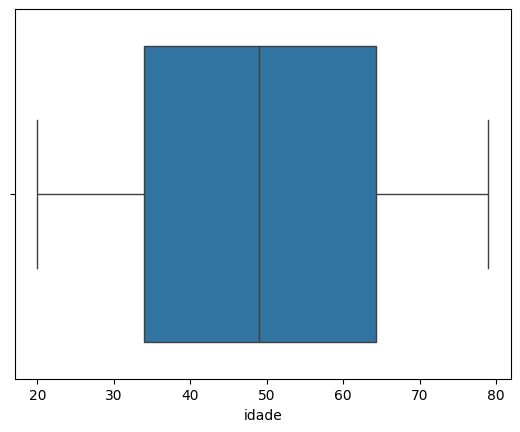

In [53]:
# Verificadr / detecar outliers
sns.boxplot(data=df_colesterol_eda, x='idade')

<Axes: xlabel='peso'>

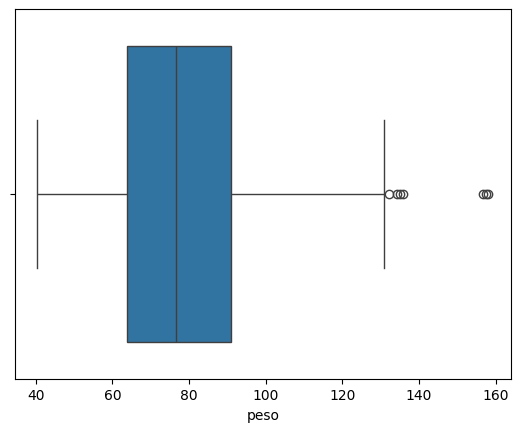

In [58]:
sns.boxplot(data=df_colesterol_eda, x='peso')

In [55]:
df_colesterol_eda[df_colesterol_eda.peso < 40]

,grupo_sanguinio,fumante,nivel_atividade_fisica,idade,peso,altura,nivel_colesterol
9,B,Sim,Alto,44,32.7,165,97.79
26,AB,Não,Alto,47,24.8,168,72.62
71,AB,Não,Alto,63,35.2,178,91.63
73,A,Não,Baixo,50,36.5,167,109.60
74,O,Sim,Moderado,43,34.5,161,111.93
79,O,Não,Moderado,45,38.1,161,120.96
87,O,Não,Alto,38,37.5,188,84.80
143,O,Não,Moderado,58,38.0,173,107.50
175,A,Não,Alto,28,37.2,166,108.82
267,A,Não,Moderado,72,36.8,165,112.05


In [56]:
# Filtrar o publico a ser removido
df_colesterol_eda[df_colesterol_eda.peso < 40].peso.count()

np.int64(37)

In [57]:
# Remover público do Dataframe
df_colesterol_eda.drop(df_colesterol_eda[df_colesterol_eda.peso < 40].index, axis=0, inplace=True)

<Axes: xlabel='altura'>

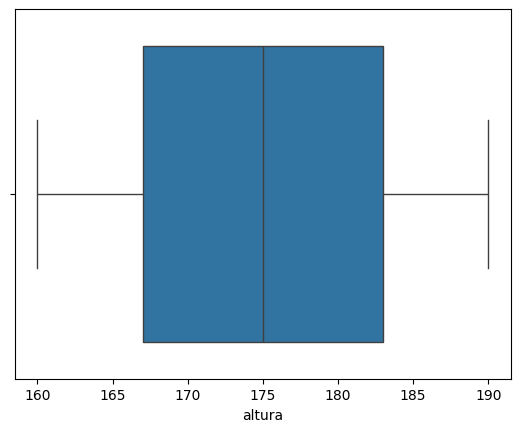

In [60]:
sns.boxplot(data=df_colesterol_eda, x='altura')

<Axes: xlabel='nivel_colesterol'>

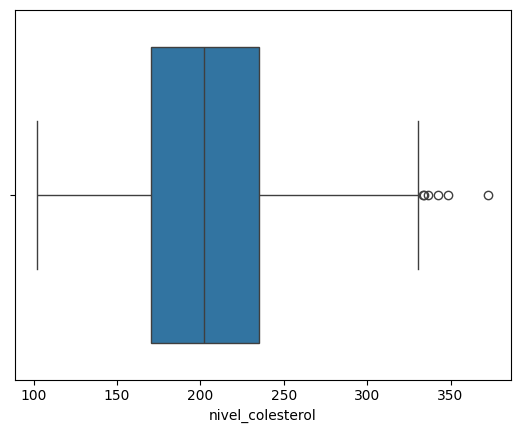

In [61]:
sns.boxplot(data=df_colesterol_eda, x='nivel_colesterol')

<Axes: xlabel='grupo_sanguinio', ylabel='nivel_colesterol'>

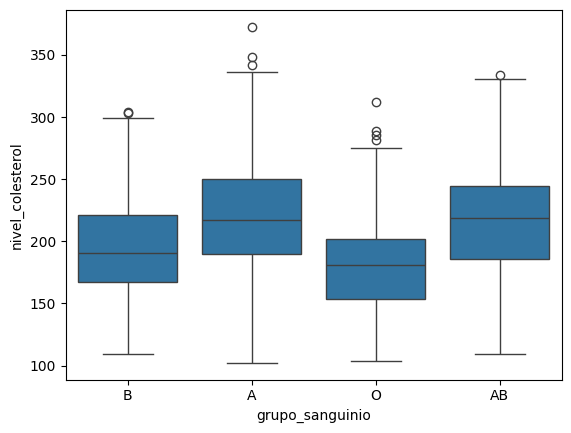

In [62]:
# Cruzamento de variaveis categoricas 
sns.boxplot(data=df_colesterol_eda, x='grupo_sanguinio', y='nivel_colesterol')

<Axes: xlabel='fumante', ylabel='nivel_colesterol'>

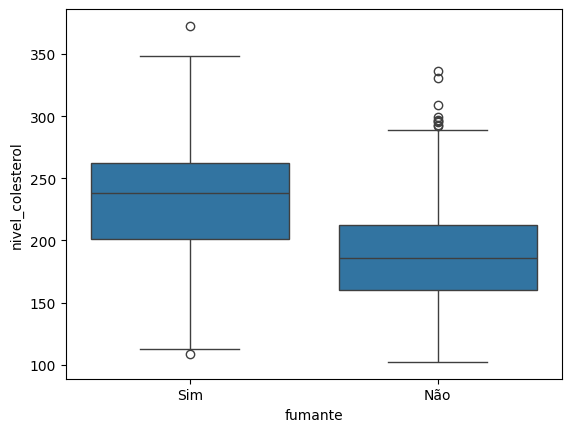

In [63]:
sns.boxplot(data=df_colesterol_eda, x='fumante', y='nivel_colesterol')

<Axes: xlabel='nivel_atividade_fisica', ylabel='nivel_colesterol'>

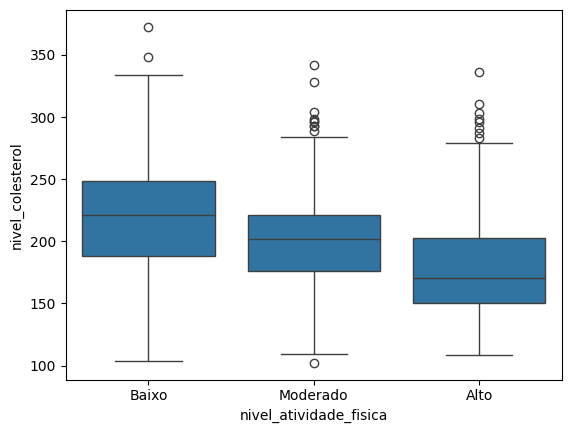

In [64]:
sns.boxplot(data=df_colesterol_eda, x='nivel_atividade_fisica', y='nivel_colesterol')